In [1]:
import cv2
import numpy as np
import os
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED'

 AMELOBLASTOMA	 DENTIGEROUS  'New list- AM,DC,KCO,SCC.gsheet'	 SQUAMOUS
 DENTAL		 KERATOCYST    ORTHOKERATINIZED


In [3]:
# Definir las rutas específicas de cada clase
folder_pathA = '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/AMELOBLASTOMA/40X'
folder_pathD = '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/DENTIGEROUS/40X'
folder_pathK = '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/KERATOCYST/40X'
folder_pathDF = '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/DENTAL/40X'
folder_pathO = '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/ORTHOKERATINIZED/40X'



In [4]:
# 3. Obtener la lista de imágenes en la carpeta
image_files = [f for f in os.listdir(folder_pathA) if f.endswith(('.png', '.jpg', '.jpeg'))]

In [ ]:
#image_files

In [5]:
#  4. Cargar imágenes, convertirlas a escala de grises y redimensionarlas a un tamaño fijo
images = []
target_size = (200, 200)  # Cambia al tamaño deseado (h, w)

for file in sorted(image_files):  # Ordena alfabéticamente
    img = cv2.imread(os.path.join(folder_pathA, file), cv2.IMREAD_GRAYSCALE)  # Leer en escala de grises
    img_resized = cv2.resize(img, target_size)  # Redimensionar
    img_flattened = img_resized.flatten()  # Convertir en un vector 1D
    images.append(img_flattened)

# 5. Convertir la lista en un solo arreglo numpy
image_matrix = np.column_stack(images)  # Cada columna es una imagen

# 6. Imprimir la forma del arreglo resultante
print("Shape del arreglo final:", image_matrix.shape)  # Debería ser (h*w, 317)



Shape del arreglo final: (40000, 317)


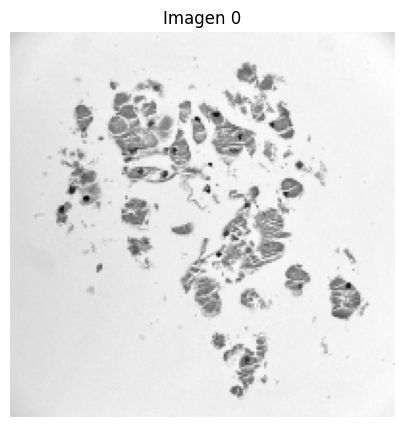

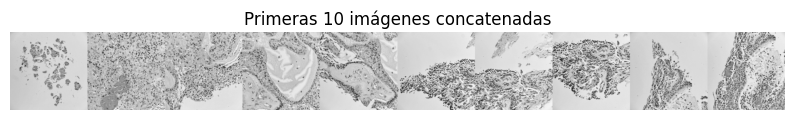

In [6]:
import matplotlib.pyplot as plt

# 1. Mostrar una imagen específica (ejemplo: la primera imagen)
index = 0  # Cambia para ver otra imagen
h, w = target_size  # Dimensiones de las imágenes
image_reshaped = image_matrix[:, index].reshape(h, w)  # Convertir columna en imagen

plt.figure(figsize=(5, 5))
plt.imshow(image_reshaped, cmap="gray")
plt.title(f"Imagen {index}")
plt.axis("off")
plt.show()

# 2. Mostrar todas las imágenes en una sola visualización
# Concatenar las primeras 10 imágenes horizontalmente para ejemplo
num_display = min(10, image_matrix.shape[1])  # Número de imágenes a mostrar
concatenated_image = np.hstack([image_matrix[:, i].reshape(h, w) for i in range(num_display)])

plt.figure(figsize=(10, 5))
plt.imshow(concatenated_image, cmap="gray")
plt.title("Primeras 10 imágenes concatenadas")
plt.axis("off")
plt.show()


In [7]:
E = image_matrix.T @ image_matrix # Change .t to .T to get the transpose of the array

In [8]:
E.shape

(317, 317)

In [9]:
# Calcular eigenvalores y eigenvectores
eigenvalues, eigenvectors = np.linalg.eigh(E)  # E ya debe estar calculada antes

# Ordenar de mayor a menor
idx = np.argsort(eigenvalues)[::-1]  # Índices ordenados en orden descendente
eigenvalues = eigenvalues[idx]  # Ordenar eigenvalores
eigenvectors = eigenvectors[:, idx]  # Ordenar eigenvectores

# Mostrar los primeros 10 eigenvalores
print("Primeros 10 eigenvalores:", eigenvalues[:10])

Primeros 10 eigenvalores: [40643.98889184  2788.78163125  2607.3449195   2556.40312862
  2542.72637618  2510.10586148  2456.08734878  2447.22591239
  2426.23148912  2401.42292629]


In [10]:
eigenvectors.shape

(317, 317)

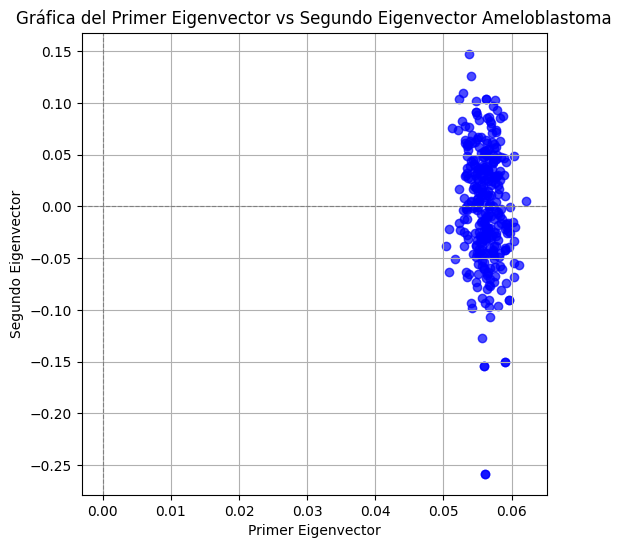

In [11]:
import matplotlib.pyplot as plt

# Tomar el primer y segundo eigenvector
eigenvector_1 = eigenvectors[:, 0]  # Primer eigenvector
eigenvector_2 = eigenvectors[:, 1]  # Segundo eigenvector

# Graficar el primer eigenvector contra el segundo
plt.figure(figsize=(6, 6))
plt.scatter(eigenvector_1, eigenvector_2, alpha=0.7, color='blue')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Primer Eigenvector")
plt.ylabel("Segundo Eigenvector")
plt.title("Gráfica del Primer Eigenvector vs Segundo Eigenvector Ameloblastoma")
plt.grid()
plt.show()


Índices de los outliers: [  9  20  33  34  39  41  42  45  49  57  61  65  77  78  79  80  84  87
  88  90  92  99 101 103 113 114 115 121 122 129 136 137 138 149 150 152
 153 155 174 176 177 179 180 181 184 185 188 199 216 218 219 221 226 228
 230 231 232 233 234 235 236 237 238 246 253 254 257 260 261 281 289 300
 305 306 315]
Número total de outliers detectados: 75


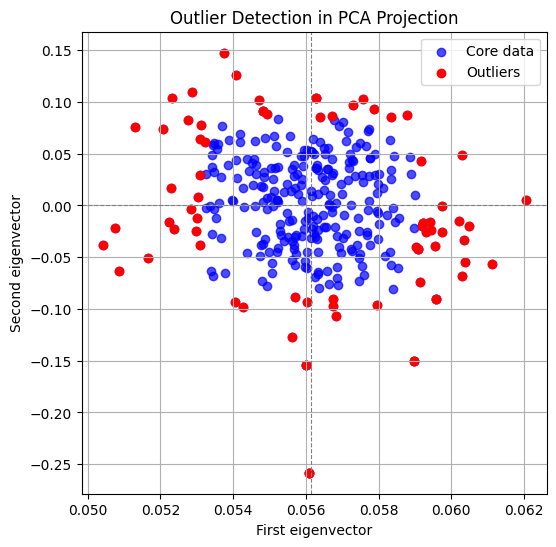

In [16]:
import numpy as np

# Calcular la proyección de los datos en los dos primeros eigenvectores
projection_1 = eigenvectors[:, 0]  # Proyección en el primer eigenvector
projection_2 = eigenvectors[:, 1]  # Proyección en el segundo eigenvector

# Calcular media y desviación estándar de cada proyección
mean_1, std_1 = np.mean(projection_1), np.std(projection_1)
mean_2, std_2 = np.mean(projection_2), np.std(projection_2)

# Detectar outliers: valores fuera de 2 desviaciones estándar
outliers_mask = ((projection_1 < mean_1 - 1.5 * std_1) | (projection_1 > mean_1 + 1.5 * std_1) |
                 (projection_2 < mean_2 - 1.5 * std_2) | (projection_2 > mean_2 + 1.5 * std_2))

# Obtener índices de los outliers
outliers_indices = np.where(outliers_mask)[0]

print("Índices de los outliers:", outliers_indices)
print("Número total de outliers detectados:", len(outliers_indices))

# Graficar los puntos y resaltar outliers
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(projection_1, projection_2, alpha=0.7, color='blue', label="Core data")
plt.scatter(projection_1[outliers_indices], projection_2[outliers_indices], color='red', label="Outliers")
plt.axhline(mean_2, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(mean_1, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("First eigenvector")
plt.ylabel("Second eigenvector")
plt.title("Outlier Detection in PCA Projection")
plt.legend()
plt.grid()
plt.show()


In [ ]:
type(outliers_indices)

numpy.ndarray

In [ ]:
import os
import shutil
import numpy as np



# Rutas de las carpetas en Drive
carpeta_origen = "/content/drive/MyDrive/Todo/Todo_Cumprum"
carpeta_destino = "/content/drive/MyDrive/Todo/Todo_Cumprum_CORE"

# Crear carpeta de destino si no existe
os.makedirs(carpeta_destino, exist_ok=True)

# Obtener lista de imágenes en la carpeta original (ordenadas)
imagenes = sorted(os.listdir(carpeta_origen))

# Vector de índices de outliers (suponiendo que ya es un numpy.ndarray)
outliers = outliers_indices  # Ejemplo, ajusta con tus datos
outliers_set = set(outliers.tolist())  # Convertir a conjunto para búsquedas rápidas

# Copiar imágenes que NO son outliers
for idx, img in enumerate(imagenes):
    if idx not in outliers_set:  # Si el índice no está en los outliers, lo copiamos
        img_path = os.path.join(carpeta_origen, img)
        shutil.copy(img_path, os.path.join(carpeta_destino, img))
        print(f"Copiada: {img}")

print("Proceso completado.")


Copiada: Copia de capt_01_1_cropped_rot0(1).png
Copiada: Copia de capt_01_1_cropped_rot0(2).png
Copiada: Copia de capt_01_1_cropped_rot0(7).png
Copiada: Copia de capt_01_1_cropped_rot0(8).png
Copiada: Copia de capt_01_1_cropped_rot0.png
Copiada: Copia de capt_01_1_cropped_rot0_mirror(1).png
Copiada: Copia de capt_01_1_cropped_rot0_mirror(2).png
Copiada: Copia de capt_01_1_cropped_rot0_mirror(7).png
Copiada: Copia de capt_01_1_cropped_rot0_mirror(8).png
Copiada: Copia de capt_01_1_cropped_rot0_mirror.png
Copiada: Copia de capt_01_1_cropped_rot180(1).png
Copiada: Copia de capt_01_1_cropped_rot180(2).png
Copiada: Copia de capt_01_1_cropped_rot180(7).png
Copiada: Copia de capt_01_1_cropped_rot180(8).png
Copiada: Copia de capt_01_1_cropped_rot180.png
Copiada: Copia de capt_01_1_cropped_rot180_mirror(1).png
Copiada: Copia de capt_01_1_cropped_rot180_mirror(2).png
Copiada: Copia de capt_01_1_cropped_rot180_mirror(7).png
Copiada: Copia de capt_01_1_cropped_rot180_mirror(8).png
Copiada: Copia d